In [1]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import shap

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [18]:
def trans_donnees(X):
    X1 = X.copy()
    
    # Suppression des variables avec trop de valeurs manquantes (>50%)
    X1.drop(columns=[
        'Numero_Conteneur_Entree', 'Salle_Balance_Entree', 'Region_Entree', 'IP_Entree',
        'Numero_Conteneur_Sortie', 'ID_Balance_Sortie', 'Region_Sortie', 'IP_Sortie',
        'Routine_Manutention', 'Numero_Sequence', 'Remarque', 'Annule', 'Annule_Par', 'Date_Annulation'
    ], inplace=True)
    
    # Suppression des doublons
    X1 = X1.drop_duplicates()
    
    # Suppression valeurs aberrantes (variables quantitatives)
    X1.loc[X1['Poids_Brut_Camion_kg'] > 100000, 'Poids_Brut_Camion_kg'] = np.nan
    X1.loc[X1['Poids_Cargaison_kg'] > 100000, 'Poids_Cargaison_kg'] = np.nan
    X1.loc[X1['Poids_Camion_Sortie_kg'] > 100000, 'Poids_Camion_Sortie_kg'] = np.nan
    X1.loc[X1['Poids_Tare_kg'] > 100000, 'Poids_Tare_kg'] = np.nan
    X1.loc[X1['Poids_Camion_Entree_kg'] > 100000, 'Poids_Camion_Entree_kg'] = np.nan
    X1.loc[X1['Surestarie_min'] > 140000, 'Surestarie_min'] = np.nan
    X1.loc[X1['Surestarie_min'] < 0, 'Surestarie_min'] = np.nan
    
    # Suppression variable redondante (corrélation = 1.00 avec Poids_Camion_Sortie_kg)
    if 'Poids_Brut_Camion_kg' in X1.columns:
        X1.drop(columns=['Poids_Brut_Camion_kg'], inplace=True)
    
    # Suppression des lignes sans variable cible
    X1.dropna(subset=['Surestarie_min'], inplace=True)
    
    # Transformation logarithmique
    log_vars = ['Surestarie_min', 'Poids_Tare_kg',
                'Poids_Cargaison_kg', 'Poids_Camion_Sortie_kg']
    for var in log_vars:
        X1[f'log_{var}'] = np.log1p(X1[var])
    
    # Typage des variables qualitatives
    var_quali = ['Nom_Cargaison', 'Nom_Navire', 'Operateur_Entree', 
                 'Operateur_Sortie', 'Type_Travail']
    for var in var_quali:
        X1[var] = X1[var].astype('object')
    
    return X1

In [19]:
train=pd.read_csv('C:/Users/LENOVO/Documents/Stage_DMP/port-ai-project/data/train.csv',index_col=0)
print(train.shape)
print(train.head())
print(train.columns)

(25498, 34)
         Numero_Camion Plaque_Camion ID_Cargaison   Connaissement  \
Statut                                                              
Gate-out    WDJB911D61     DJB911D61  DC240305005               2   
Gate-out  VCH042677500   CH042677500  DC240219002       TABUK0001   
Gate-out  VCH043848864   CH043848864  DC230909091   NSSCB23002351   
Gate-out     WETA18383      ETA18383  DC240224088  HK23170XDBT016   
Gate-out     WETA22810      ETA22810  DC240505007  NJ2401LYGDJ202   

                                   Numero_Marque  Nom_Cargaison   Nom_Navire  \
Statut                                                                         
Gate-out                      MILLINGWHEATINBULK          Wheat  BOS BOUTROS   
Gate-out                       JTMAA7BJ4P4063170        Vehicle  BAHRI TABUK   
Gate-out                       RKLKABAG3P0509459        Vehicle      JIGJIGA   
Gate-out  CCCC-FHECETHIOPIAEAHPROJECTVIADJIBOUTI         *Rebar     HELENA K   
Gate-out          BELTCO

In [20]:
train.dtypes

Numero_Camion               object
Plaque_Camion               object
ID_Cargaison                object
Connaissement               object
Numero_Marque               object
Nom_Cargaison               object
Nom_Navire                  object
Voyage                      object
Poids_Brut_Camion_kg       float64
Poids_Tare_kg              float64
Poids_Cargaison_kg         float64
Heure_Entree_Gate           object
Heure_Sortie_Gate           object
Surestarie_min               int64
Numero_Pesee                object
Numero_Conteneur_Entree    float64
Salle_Balance_Entree       float64
Region_Entree              float64
IP_Entree                  float64
Poids_Camion_Entree_kg     float64
Operateur_Entree            object
Numero_Conteneur_Sortie    float64
ID_Balance_Sortie          float64
Region_Sortie              float64
IP_Sortie                  float64
Poids_Camion_Sortie_kg     float64
Operateur_Sortie            object
Type_Travail                object
Routine_Manutention 

In [21]:
train=trans_donnees(train)
X_train=train.drop(['Surestarie_min'],axis=1)
y_train=train['Surestarie_min']

In [23]:
val=pd.read_csv('C:/Users/LENOVO/Documents/Stage_DMP/port-ai-project/data/validation.csv',index_col=0)
print(val.head())

         Numero_Camion Plaque_Camion ID_Cargaison   Connaissement  \
Statut                                                              
Gate-out    WDJB288D62     DJB288D62  DC240214010   SSMCB24000009   
Gate-out      WET88021       ET88021  DC240114020   SSMCB24000002   
Gate-out  VCH042736646   CH042736646  DC240224043  HK23170LDBT044   
Gate-out     WETA10211      ETA10211  DC240123018   SSMCB24000005   
Gate-out     WET526D67      ET526D67  DC231121003        MZDDJI01   

                             Numero_Marque Nom_Cargaison    Nom_Navire Voyage  \
Statut                                                                          
Gate-out                    NPSBFERTILIZER    Fertilizer        ZURICH  12024   
Gate-out                    NPSBFERTILIZER    Fertilizer        SABAEK  04L23   
Gate-out                 LZZ5ELSC8PN256285       Vehicle      HELENA K  23170   
Gate-out                     NPSFERTILIZER    Fertilizer       CORINNA     49   
Gate-out  NONALLOYSTEELBILLETS

In [24]:
val=trans_donnees(val)
X_val=val.drop(['Surestarie_min'],axis=1)
y_val=val['Surestarie_min']

In [25]:
#gestion des valeurs manquantes
#techniques utilisables
#ne conserver que les donnees complètes : aucun dans notre situation
#remplissage simple : moyenne pour les variables : et mode pour les variables
#KNN
#imputation itérative

In [27]:
# Création des différents jeux de données avec utilisation d'un pipeline

var_quali = ['Nom_Cargaison', 'Nom_Navire', 'Operateur_Entree', 
             'Operateur_Sortie', 'Type_Travail']

var_quanti = ['Poids_Tare_kg', 'Poids_Cargaison_kg', 
              'Poids_Camion_Entree_kg', 'Poids_Camion_Sortie_kg']

# sans Surestarie_min puisque c'est la variable à prédire

var_moy = ['Poids_Tare_kg', 'Poids_Camion_Entree_kg']
var_med = ['Poids_Cargaison_kg', 'Poids_Camion_Sortie_kg']


### Imputation Simple

In [28]:
cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy="most_frequent")),
    ('onehot',OneHotEncoder(drop='first',handle_unknown='ignore'))
])#permet d'enchainer les deux sur la même variable
preprocessor_simple=ColumnTransformer([#chaque ligne est indpendante, impératif qu'une variable ne passe que dans une ligne
    ('num_med',SimpleImputer(strategy="median"), var_med),
    ('num_moy',SimpleImputer(strategy="mean"),var_moy),
    ('cat',cat_pipeline,var_quali)#comme deux lignes sur les quali=> un pipeline qui englobe les deux lignes
])
pipe_simple_reg=Pipeline([
    ('comp',preprocessor_simple),
    ('reg',LinearRegression())
])

In [29]:
X_train.shape

(25497, 22)

In [30]:
#Entrainement
pipe_simple_reg.fit(X_train,y_train)
#prediction sur train
y_pred_train=pipe_simple_reg.predict(X_train)
#prediction sur test
y_pred_val=pipe_simple_reg.predict(X_val)

In [31]:
def qualite_reg(y,y_pred):
    mse=mean_squared_error(y,y_pred)
    print("MSE:",mse)
    print("RMSE",np.sqrt(mse))
    print("R²:",r2_score(y,y_pred))
    print("MAE",mean_absolute_error(y,y_pred))

In [32]:
#résultat obtenus en apprentissage
print("apprentissage")
qualite_reg(y_train,y_pred_train)
#résultat obtenus en validation
print('validation')
qualite_reg(y_val,y_pred_val)

apprentissage
MSE: 3028085.3389290795
RMSE 1740.1394596207165
R²: 0.043795738780441296
MAE 577.6305506096725
validation
MSE: 1776008.9617811905
RMSE 1332.6698622619147
R²: 0.07038074354626955
MAE 561.1736104876113


### Imputation KNN

In [33]:
#avec une imputation KNN
cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy="most_frequent")),
    ('onehot',OneHotEncoder(drop='first',handle_unknown='ignore'))
])#permet d'enchainer les deux sur la même variable
preprocessor_simple=ColumnTransformer([#chaque ligne est indpendante, impératif qu'une variable ne passe que dans une ligne
    ('num_KNN',KNNImputer(n_neighbors=5),var_quanti),
    ('cat',cat_pipeline,var_quali)#comme deux lignes sur les quali=> un pipeline qui englobe les deux lignes
])
pipe_KNN_reg=Pipeline([
    ('comp',preprocessor_simple),
    ('reg',LinearRegression())
])

In [34]:
#Entrainement
pipe_KNN_reg.fit(X_train,y_train)
#prediction sur train
y_pred_train=pipe_KNN_reg.predict(X_train)
#prediction sur test
y_pred_val=pipe_KNN_reg.predict(X_val)

In [35]:
#résultat obtenus en apprentissage
print("apprentissage")
qualite_reg(y_train,y_pred_train)
#résultat obtenus en validation
print('validation')
qualite_reg(y_val,y_pred_val)

apprentissage
MSE: 3028962.894239026
RMSE 1740.3915922110823
R²: 0.04351862567664644
MAE 578.8448316671805
validation
MSE: 1776672.9232950178
RMSE 1332.918948509255
R²: 0.07003320509230881
MAE 561.8276763976608


### Imputation Iteratives 

In [21]:
#Avec une imputation iterative : bayesianRidge
cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy="most_frequent")),
    ('onehot',OneHotEncoder(drop='first',handle_unknown='ignore'))
])#permet d'enchainer les deux sur la même variable
preprocessor_simple=ColumnTransformer([#chaque ligne est indpendante, impératif qu'une variable ne passe que dans une ligne
    ('num_BR',IterativeImputer(estimator=BayesianRidge(),max_iter=10,random_state=2026),var_quanti),
    ('cat',cat_pipeline,var_quali)#comme deux lignes sur les quali=> un pipeline qui englobe les deux lignes
])
pipe_IIBR_reg=Pipeline([
    ('comp',preprocessor_simple),
    ('reg',LinearRegression())
])

In [22]:
#Entrainement
pipe_IIBR_reg.fit(X_train,y_train)
#prediction sur train
y_pred_train=pipe_IIBR_reg.predict(X_train)
#prediction sur test
y_pred_val=pipe_IIBR_reg.predict(X_val)

In [23]:
#résultat obtenus en apprentissage
print("apprentissage")
qualite_reg(y_train,y_pred_train)
#résultat obtenus en validation
print('validation')
qualite_reg(y_val,y_pred_val)

apprentissage
MSE: 3050570.5485176826
RMSE 1746.5882595842909
R²: 0.03669539291283075
MAE 576.3091010996123
validation
MSE: 1799265.810310111
RMSE 1341.3671422508123
R²: 0.05820737353397587
MAE 560.3387528677299


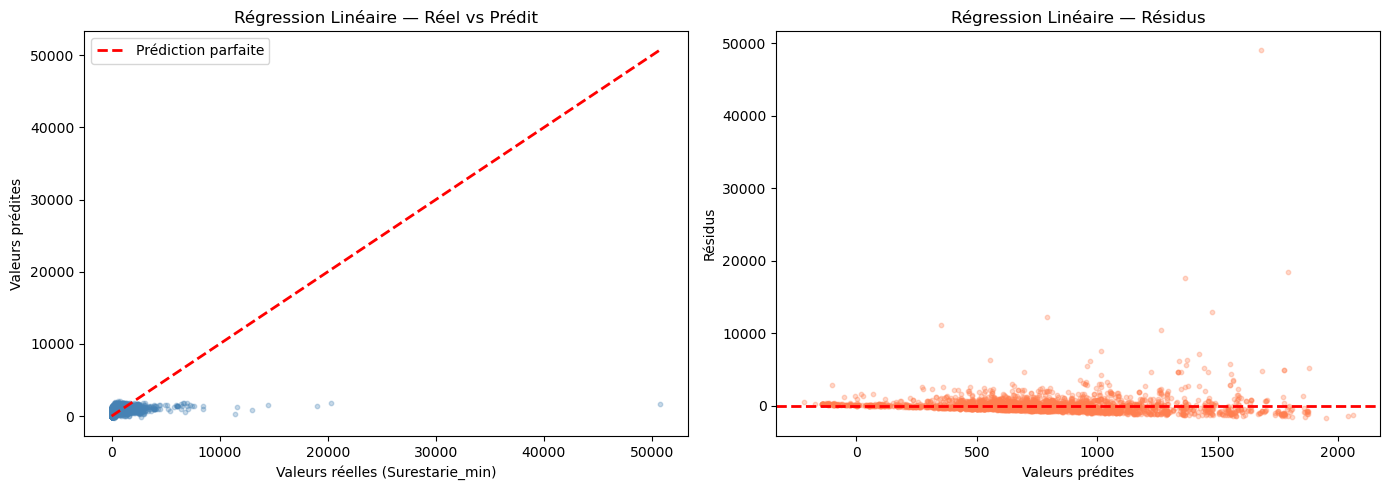

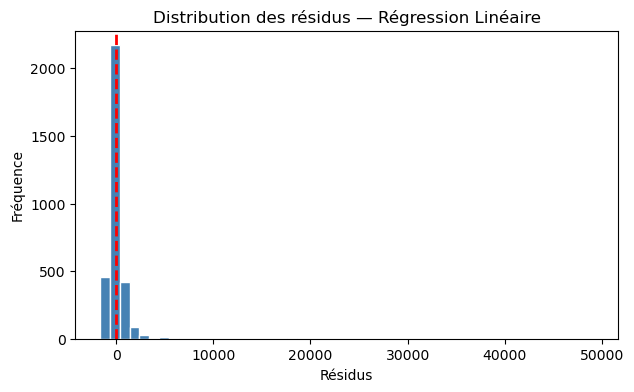

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Prédictions
y_pred_train = pipe_simple_reg.predict(X_train)
y_pred_val = pipe_simple_reg.predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Graphique 1 : Valeurs réelles vs prédites ──
axes[0].scatter(y_val, y_pred_val, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_val.min(), y_val.max()], 
             [y_val.min(), y_val.max()], 
             color='red', linewidth=2, linestyle='--', label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (Surestarie_min)')
axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title('Régression Linéaire — Réel vs Prédit')
axes[0].legend()

# ── Graphique 2 : Résidus ──
residus = y_val - y_pred_val
axes[1].scatter(y_pred_val, residus, alpha=0.3, color='coral', s=10)
axes[1].axhline(y=0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Valeurs prédites')
axes[1].set_ylabel('Résidus')
axes[1].set_title('Régression Linéaire — Résidus')

plt.tight_layout()
plt.show()

# ── Graphique 3 : Distribution des résidus ──
plt.figure(figsize=(7, 4))
plt.hist(residus, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linewidth=2, linestyle='--')
plt.xlabel('Résidus')
plt.ylabel('Fréquence')
plt.title('Distribution des résidus — Régression Linéaire')
plt.show()

Shape des données : (25497, 228)
Nombre de features : 228


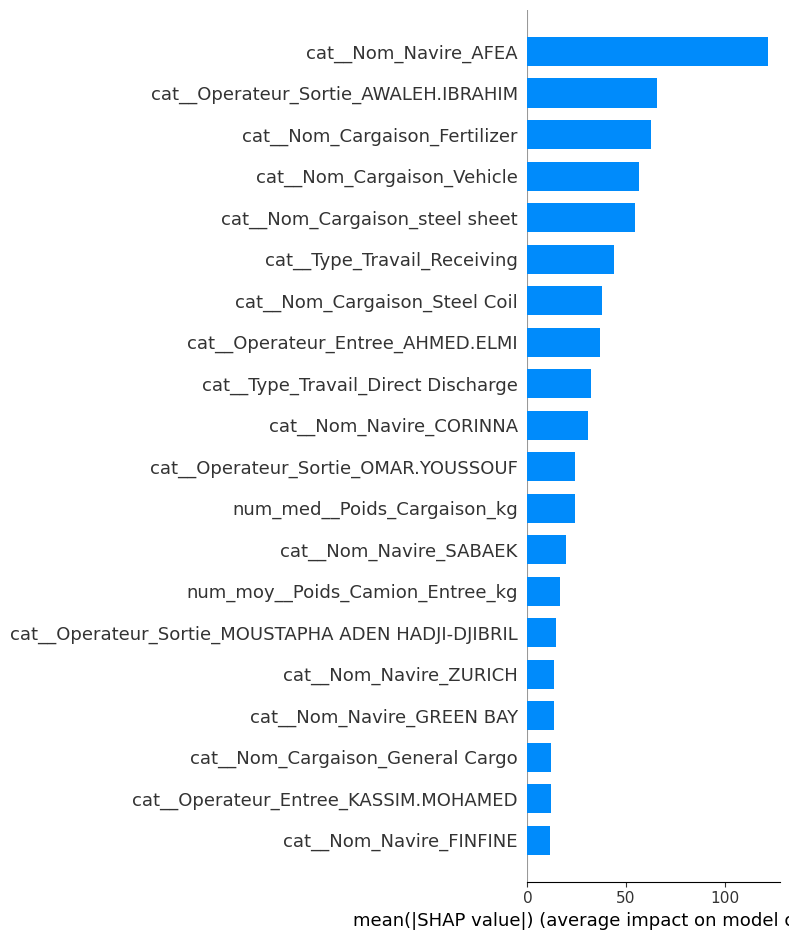

In [28]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# =========================
# Entraînement du modèle
# =========================

pipe_simple_reg.fit(X_train, y_train)

# =========================
# Transformation des données
# =========================

# récupérer le preprocess
preprocess = pipe_simple_reg.named_steps["comp"]

# transformer les données
X_train_trans = preprocess.transform(X_train)

# convertir sparse -> dense si nécessaire
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()

# récupérer les noms des variables
feature_names = preprocess.get_feature_names_out()

# vérifier les dimensions
print("Shape des données :", X_train_trans.shape)
print("Nombre de features :", len(feature_names))

# création DataFrame
X_train_trans = pd.DataFrame(
    X_train_trans,
    columns=feature_names,
    index=X_train.index
)

# =========================
# SHAP Linear Explainer
# =========================

# récupérer le modèle de régression
model = pipe_simple_reg.named_steps["reg"]

# créer l'explainer
explainer = shap.LinearExplainer(
    model,
    X_train_trans,
    feature_perturbation="interventional"
)

# =========================
# Calcul des SHAP values
# =========================

shap_values = explainer.shap_values(X_train_trans)

# =========================
# Visualisation
# =========================

shap.summary_plot(
    shap_values,
    X_train_trans,
    feature_names=X_train_trans.columns,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

In [ ]:
# Visualisation confirme que la Régression Linéaire est inadaptée :
# - Sous-estimation massive des grandes surestaries
# - Hétéroscédasticité des résidus
# - Relation clairement non-linéaire entre les features et Surestarie_min
# → Passage aux modèles non-linéaires : KNN, Decision Tree, Random Forest

#### Conclusion 

In [ ]:
# Modèle le plus efficace sur la régression linéaire : l'imputation simple
# mais la régression linéaire n'est pas apte avec notre phénomène
# R² max = 0.07 → seulement 7% de la variance expliquée
# Le phénomène de surestarie est non-linéaire → passer aux modèles non-linéaires